In [1]:
using Pkg
Pkg.activate(joinpath(@__DIR__, "..","DTENV"))
Pkg.instantiate()
include("../scripts/TesselationCore.jl")
if size(LOAD_PATH,1) < 4
    push!(LOAD_PATH, joinpath(@__DIR__,"..","scripts"))
end


  Activating project at `c:\Users\Ivan\Desktop\Stuff4School\Thesis\CleanDTFE\DTENV`


4-element Vector{String}:
 "@"
 "@v#.#"
 "@stdlib"
 "c:\\Users\\Ivan\\Desktop\\Stuff4School\\Thesis\\CleanDTFE\\notebooks\\..\\scripts"

In [2]:
using TetGen
using StaticArrays
using GLMakie
using JLD
using BenchmarkTools
using LinearAlgebra
using Plots

import .TesselationCore


In [3]:
points3d = [TesselationCore.point3(@SVector rand(3)) for _ in 1:50]
coords, tets = TesselationCore.tesselate(points3d)
simplices = Vector([coords[:,tets[i,:]]' for i in 1:size(tets,1)])
simplex = simplices[1]


4×3 adjoint(::Matrix{Float64}) with eltype Float64:
 0.10496     0.817862  0.159852
 0.0855142   0.613379  0.200678
 0.106294    0.622332  0.523706
 0.00997221  0.688878  0.780656

In [9]:
abstract type TreeNode end

struct BVHLeaf <: TreeNode
    data::Vector{Int}
end

struct BVHNode <: TreeNode
    depth::Int
    leftChild::TreeNode  #unions are apparently slow. We'll see with some benchmars
    rightChild::TreeNode
    data::Vector{Int} 
end


struct BVH
    tree::TreeNode
    bbox::Matrix{Float64}   
end

function generateBVHTree(boxes,depth::Int,limBox::Matrix)
    indices = 1:size(boxes,3)
    return generateBVHTree(boxes,depth,limBox,indices)
end

function generateBVHTree(boxes,depth::Int,limBox::Matrix, indices)
    
    if depth == 0 || size(boxes,3) < 2 
        if depth!=0
            println("Nontrivial leaf $depth") #REMOVE BEFORE PROD
        end
        return BVHLeaf(indices)
    end
    
    ax = depth%3 + 1

    mins = boxes[ax,1,indices]
    maxs = boxes[ax,2,indices]
    
    line = (limBox[ax,2]+limBox[ax,1])/2 

    leftIDs = indices[mins .≤ line]
    rightIDs = indices[maxs .≥ line]

    leftBox = copy(limBox)
    leftBox[ax,2] = line
    
    rightBox = copy(limBox)
    rightBox[ax,1] = line

    return BVHNode(depth,
    generateBVHTree(boxes,depth-1,leftBox,leftIDs),
    generateBVHTree(boxes,depth-1,rightBox,rightIDs),
    indices)
end


function BVH(data::Vector,depth::Int)
    boxes = stack([cornerSimplexMatr(simplex) for simplex in data])

    minima = (minimum(boxes[1,1,:]),minimum(boxes[2,1,:]),minimum(boxes[3,1,:]))
    maxima = (maximum(boxes[1,2,:]),maximum(boxes[2,2,:]),maximum(boxes[3,2,:]))

    box = stack([minima,maxima])
    tree = generateBVHTree(boxes,depth,box)
    
    return BVH(tree,box)
end

function BVH(data::Vector,depth::Int,box::Matrix)
    boxes = stack([cornerSimplexMatr(simplex) for simplex in data])

    tree = generateBVHTree(boxes,depth,box)
    return BVH(tree,box)
end

function cornerSimplexMatr(simplex)
    return hcat(minimum(simplex,dims=1)',maximum(simplex,dims=1)') 
end



cornerSimplexMatr (generic function with 1 method)

In [ ]:
timeNew = []
errNew = []

T = [1,3,6,9,12,15,18]

for t in T
    bench = @benchmarkable BVH(simplices,$t)
    stats = run(bench)
    push!(timeNew,mean(stats).time)
    push!(errNew,std(stats).time)
end


1369121518

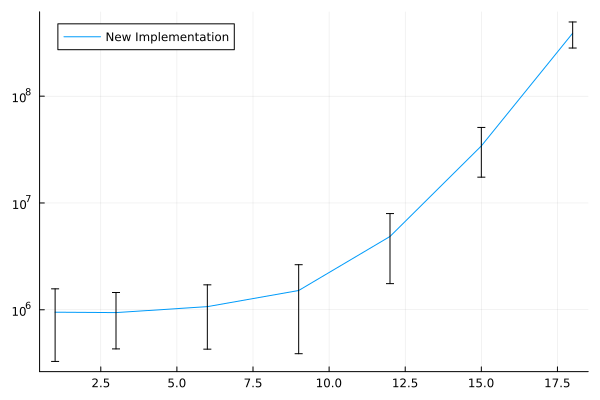

In [16]:
Plots.plot(T,timeNew,yerr=errNew,yscale=:log10,label="New Implementation")

In [17]:
struct BVHTreeOld
    depth::Int
    rightChild::Union{Nothing,BVHTreeOld}
    leftChild::Union{Nothing,BVHTreeOld} 
    data::Vector{Int}  
end

struct BVHOld
    tree::BVHTreeOld
    bbox::Matrix{Float64}   
end

function generateBVHTreeOld(boxes,depth::Int,limBox::Matrix)
    indices = 1:size(boxes,3)

    return generateBVHTreeOld(boxes,depth,limBox,indices)
    
end

function generateBVHTreeOld(boxes,depth::Int,limBox::Matrix, indices)
    
    if depth == 0 || size(boxes,3) < 2 
        if depth!=0
            println("Nontrivial leaf $depth") #REMOVE BEFORE PROD
        end
        return BVHTreeOld(0,nothing,nothing,indices)
    end
    
    ax = depth%3 + 1

    mins = boxes[ax,1,indices]
    maxs = boxes[ax,2,indices]
    
    line = (limBox[ax,2]+limBox[ax,1])/2 

    leftIDs = indices[mins .≤ line]
    rightIDs = indices[maxs .≥ line]

    leftBox = copy(limBox)
    leftBox[ax,2] = line
    
    rightBox = copy(limBox)
    rightBox[ax,1] = line

    return BVHTreeOld(depth,
    generateBVHTreeOld(boxes,depth-1,rightBox,rightIDs),
    generateBVHTreeOld(boxes,depth-1,leftBox,leftIDs), # I WAS CALLING IT IN REVERSE AND WONDERING WHY IT'S BROKEN
    indices)
end


function BVHOld(data::Vector,depth::Int)
    boxes = stack([cornerSimplexMatr(simplex) for simplex in data])

    minima = (minimum(boxes[1,1,:]),minimum(boxes[2,1,:]),minimum(boxes[3,1,:]))
    maxima = (maximum(boxes[1,2,:]),maximum(boxes[2,2,:]),maximum(boxes[3,2,:]))

    box = stack([minima,maxima])


    tree = generateBVHTreeOld(boxes,depth,box)
    
    return BVHOld(tree,box)
end

function BVHOld(data::Vector,depth::Int,box::Matrix)
    boxes = stack([cornerSimplexMatr(simplex) for simplex in data])

    tree = generateBVHTree(boxes,depth,box)
    return BVHOld(tree,box)
end

function cornerSimplexMatr(simplex)
    return hcat(minimum(simplex,dims=1)',maximum(simplex,dims=1)') 
end



cornerSimplexMatr (generic function with 1 method)

In [18]:
timeClassic = []
errClassic = []

T = [1,3,6,9,12,15,18]

for t in T
    bench = @benchmarkable BVHOld(simplices,$t)
    stats = run(bench)
    push!(timeClassic,mean(stats).time)
    push!(errClassic,std(stats).time)
end


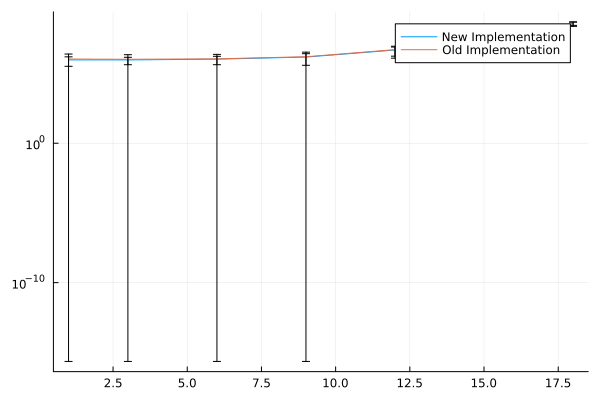

In [ ]:
plot = Plots.plot(T,timeNew,yerr=errNew,yscale=:log10,label="New Implementation")
Plots.plot!(T,timeClassic,yerr=errClassic,yscale=:log10,label="Old Implementation")
plot

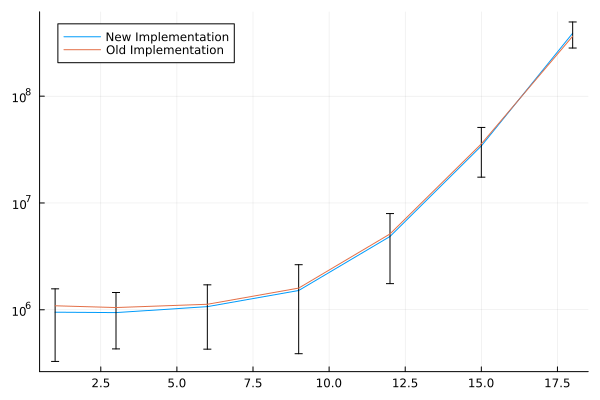

In [22]:
plot = Plots.plot(T,timeNew,yerr=errNew,yscale=:log10,label="New Implementation")
Plots.plot!(T,timeClassic,yscale=:log10,label="Old Implementation")
plot

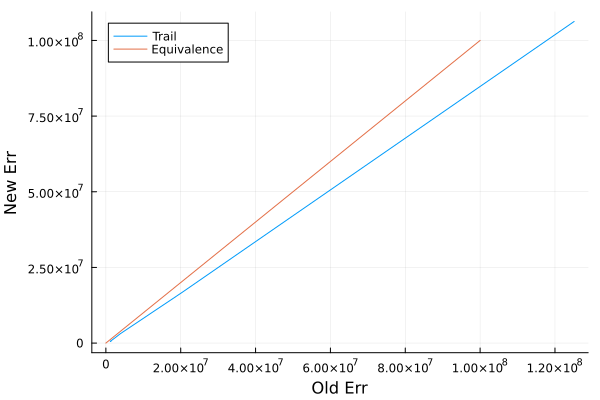

In [28]:
Plots.plot(errClassic,errNew,ylabel="New Err",xlabel="Old Err",label="Trail")
Plots.plot!([0,1e8],[0,1e8],label="Equivalence")

The slope is less than 1, so The new implementation has consistently lower error, i.e. variation, in other words it performs more consistently.